In [133]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# ML Algorithms
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor, StackingRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("laptop_data.csv")

In [3]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


# Exploratory Data Analysis (EDA)

In [4]:
df.shape

(1303, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [6]:
df.duplicated().sum()

# output: 0 --> No duplicate rows in the dataset

np.int64(0)

In [7]:
df.isnull().sum()

# output: all 0 --> No null values in the dataset

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

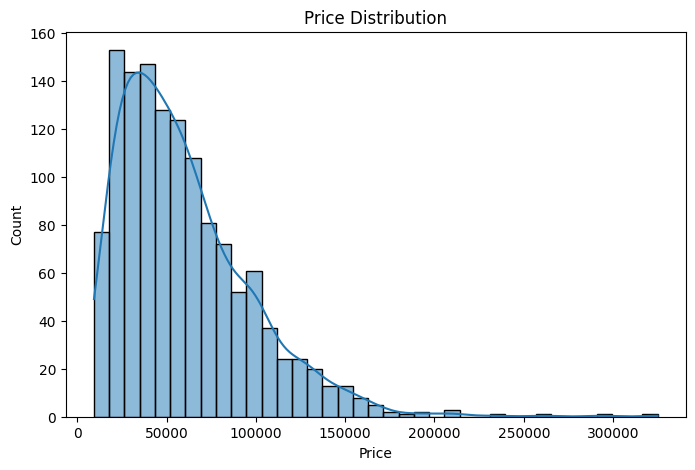

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True)

plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Distribution")

plt.show()

##### The price distribution is positively skewed, meaning most laptops are in the lower-to-mid price range while only a few laptops are very expensive.

<Axes: xlabel='Company'>

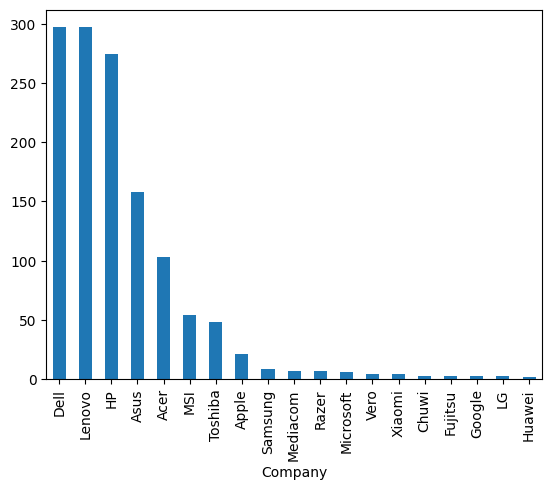

In [9]:
df['Company'].value_counts().plot(kind='bar')

##### 1. Dell, Lenovo, and HP have the highest number of laptops in the dataset, indicating they are the most common brands.

##### 2. Some companies like Huawei, LG, Google, and Fujitsu have very few laptop entries, showing an imbalanced distribution among brands.


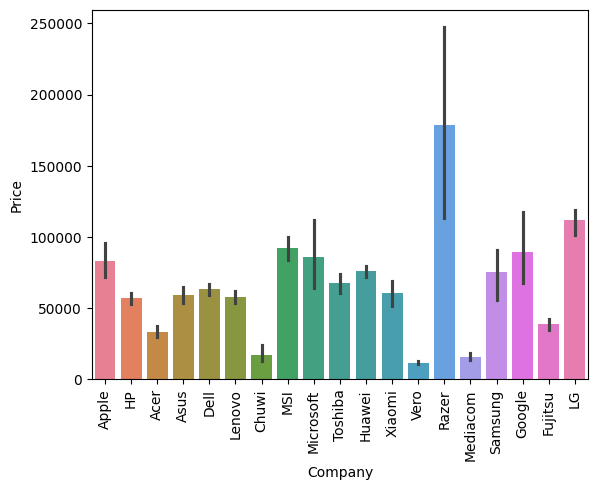

In [10]:
sns.barplot(x=df['Company'],y=df['Price'],hue=df['Company'])
plt.xticks(rotation='vertical')
plt.show()

##### 1. Razer, LG, MSI, and Google laptops have the highest average prices, indicating they mainly focus on premium or high-performance devices.

##### 2. Companies like Acer, Chuwi, Mediacom, and Vero offer comparatively lower-priced laptops, suggesting they target the budget segment.


<Axes: xlabel='TypeName'>

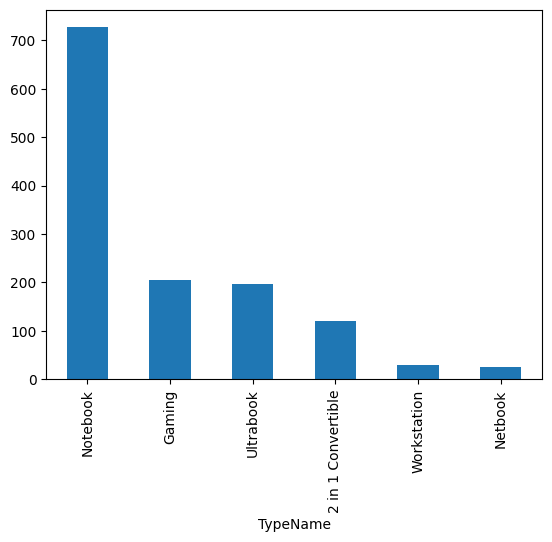

In [11]:
df['TypeName'].value_counts().plot(kind='bar')

##### 1. Notebook laptops dominate the dataset, showing that standard laptops are the most commonly available type.

##### 2. Workstations and Netbooks have very few entries, indicating these laptop categories are less common in the market.


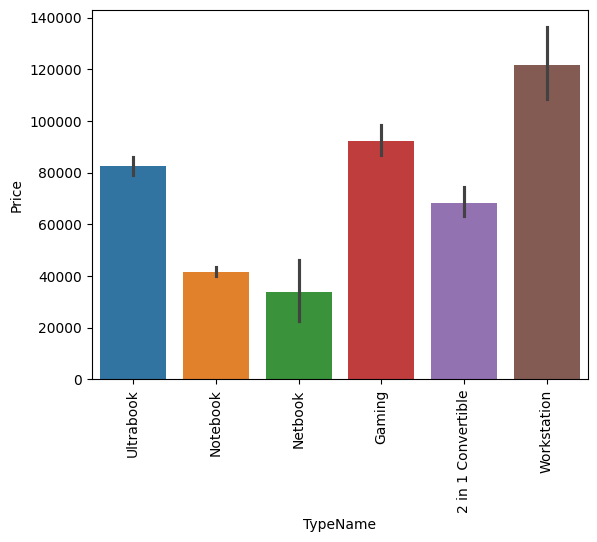

In [12]:
sns.barplot(
    x=df['TypeName'],
    y=df['Price'],
    hue=df['TypeName']   # different color for each bar/category
)

plt.xticks(rotation='vertical')
plt.show()

##### 1. Workstation and Gaming laptops have the highest average prices, indicating they are designed for high-performance and professional tasks.

##### 2. Netbooks and standard Notebooks are the least expensive categories, mainly targeting basic and budget-friendly usage.


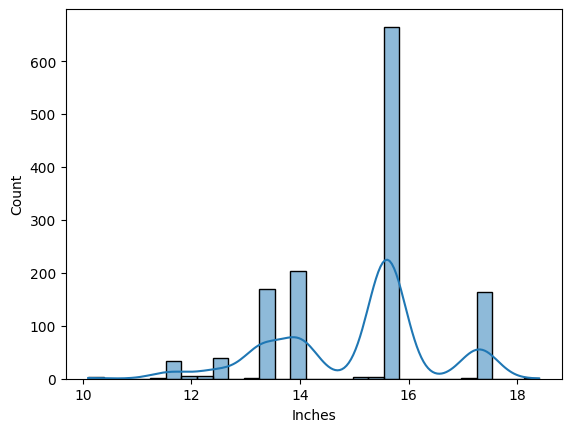

In [13]:
sns.histplot(df['Inches'], kde=True)
plt.show()

##### 1. Most laptops in the dataset have screen sizes around 15.6 inches, making it the most common laptop size.

##### 2. Smaller sizes like 11–13 inches and larger sizes around 17 inches are less frequent, indicating fewer compact and gaming/workstation laptops.


<Axes: xlabel='Inches', ylabel='Price'>

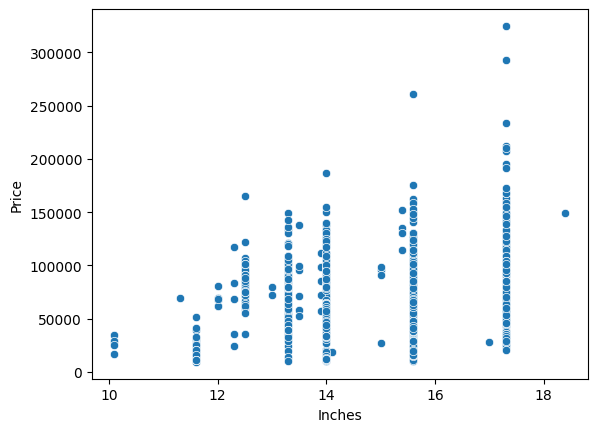

In [14]:
sns.scatterplot(x=df['Inches'],y=df['Price'])

##### 1. There is a slight positive relationship between laptop screen size and price, as larger laptops generally tend to be more expensive.

##### 2. However, the wide spread of points shows that screen size alone does not strongly determine price, and other features also play an important role.


# **Preprocessing**

In [15]:
df.sample(5)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
590,590,Asus,2 in 1 Convertible,15.6,Touchscreen 1366x768,Intel Core i5 7200U 2.5GHz,8GB,1TB HDD,Intel HD Graphics 520,Windows 10,2.2kg,39373.920
418,418,Dell,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,8GB,1TB HDD,Intel HD Graphics 620,Windows 10,2.14kg,28768.536
808,808,Dell,Gaming,15.6,4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1050 Ti,Windows 10,2.62kg,89457.120
169,169,HP,Notebook,13.3,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,4GB,500GB HDD,Intel UHD Graphics 620,Windows 10,1.49kg,40173.120
1198,1198,Acer,Notebook,15.6,1366x768,Intel Celeron Dual Core N3350 2GHz,4GB,1TB HDD,Intel HD Graphics 500,Linux,2.1kg,14492.160


In [16]:
# Remove the 'Unnamed: 0' column
df.drop(columns = ['Unnamed: 0'],inplace=True)

In [17]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1265,Lenovo,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,1TB HDD,Nvidia GeForce GTX 960M,Windows 10,2.6kg,47898.720
514,Xiaomi,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,256GB SSD,Nvidia GeForce MX150,No OS,1.95kg,74589.336
368,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,256GB SSD,AMD Radeon R7 M445,Windows 10,2.33kg,47898.720
250,Dell,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 8550U 1.8GHz,8GB,1TB HDD,Intel UHD Graphics 620,Windows 10,2.08kg,43636.320
1205,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,AMD Radeon R7 M445,Windows 10,2.36kg,47365.920


In [18]:
# Remove 'GB' from RAM column 
df['Ram'] = df['Ram'].str.replace('GB','')

# Remove 'kg' from Weight column
df['Weight'] = df['Weight'].str.replace('kg','')

In [19]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
129,HP,Notebook,17.3,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,Windows 10,2.5,49443.84
333,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,4,1TB HDD,Intel HD Graphics 520,Windows 10,1.85,23922.72
1255,Asus,Notebook,15.6,1366x768,Intel Celeron Dual Core N3350 1.1GHz,4,1TB HDD,Intel HD Graphics 500,Windows 10,2,18061.92
405,Asus,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8,512GB SSD,Intel HD Graphics 620,Windows 10,1.10,99793.44
880,HP,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,4,256GB SSD,Intel HD Graphics 620,Windows 10,1.28,90576.00


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   object 
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   object 
 10  Price             1303 non-null   float64
dtypes: float64(2), object(9)
memory usage: 112.1+ KB


In [21]:
# convert the data type of 'Ram' from object to int
df['Ram'] = df['Ram'].astype('int')


# convert the data type of 'Weight' from object to float
df['Weight'] = df['Weight'].astype('float')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int64  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
dtypes: float64(3), int64(1), object(7)
memory usage: 112.1+ KB


# **Feature Engineering** 

In [23]:
df['ScreenResolution'].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2304x1440                 6
IPS Panel Retina Display 2560x1600                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

In [24]:
df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)

0       0
1       0
2       0
3       0
4       0
       ..
1298    1
1299    1
1300    0
1301    0
1302    0
Name: ScreenResolution, Length: 1303, dtype: int64

### Touchscreen Column

In [25]:
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)

In [26]:
df.tail(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.64,1
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.72,1
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.12,0
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.92,0
1302,Asus,Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4,500GB HDD,Intel HD Graphics,Windows 10,2.20,19660.32,0


In [27]:
df['Touchscreen'].value_counts()

Touchscreen
0    1111
1     192
Name: count, dtype: int64

<Axes: xlabel='Touchscreen'>

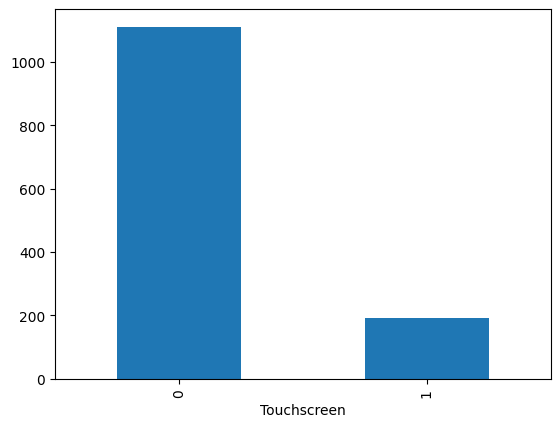

In [28]:
df['Touchscreen'].value_counts().plot(kind='bar')

<Axes: xlabel='Touchscreen', ylabel='Price'>

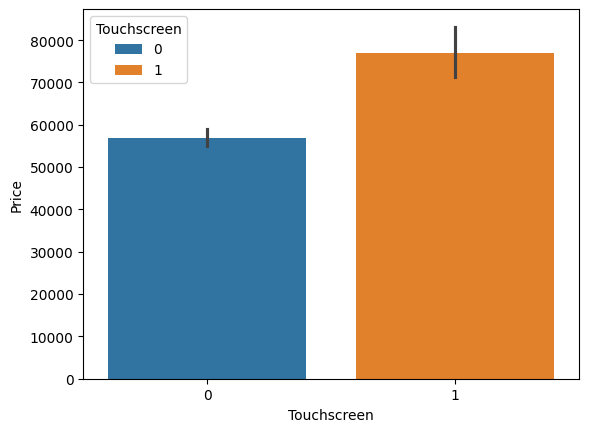

In [29]:
sns.barplot(x=df['Touchscreen'],y=df['Price'],hue=df['Touchscreen'])

### IPS Panel

In [30]:
df['IPS'] = df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)

In [31]:
df.tail(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.64,1,1
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.72,1,1
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.12,0,0
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.92,0,0
1302,Asus,Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4,500GB HDD,Intel HD Graphics,Windows 10,2.20,19660.32,0,0


In [32]:
df['IPS'].value_counts()

IPS
0    938
1    365
Name: count, dtype: int64

<Axes: xlabel='IPS'>

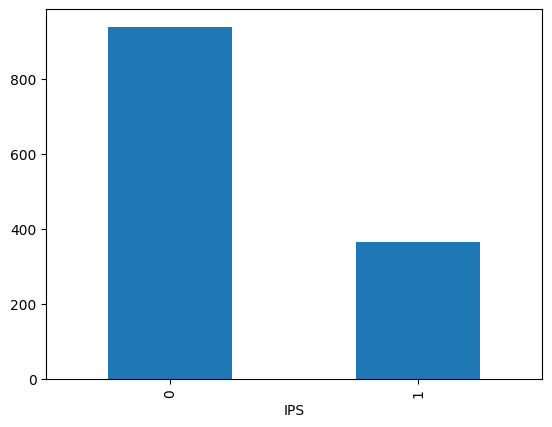

In [33]:
df['IPS'].value_counts().plot(kind='bar')

<Axes: xlabel='IPS', ylabel='Price'>

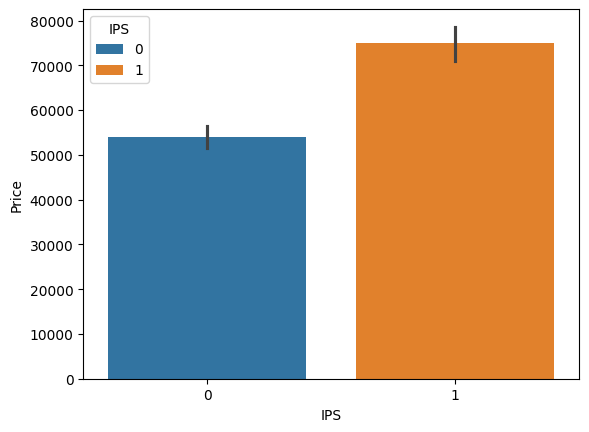

In [34]:
sns.barplot(x=df['IPS'],y=df['Price'],hue=df['IPS'])

### X-Resolution

In [35]:
new = df['ScreenResolution'].str.split('x',n=1,expand=True)
new

,0,1
0,IPS Panel Retina Display 2560,1600
1,1440,900
2,Full HD 1920,1080
3,IPS Panel Retina Display 2880,1800
4,IPS Panel Retina Display 2560,1600
...,...,...
1298,IPS Panel Full HD / Touchscreen 1920,1080
1299,IPS Panel Quad HD+ / Touchscreen 3200,1800
1300,1366,768
1301,1366,768


In [36]:
df['X_res'] = new[0]
df['Y_res'] = new[1]

In [37]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,X_res,Y_res
795,Lenovo,2 in 1 Convertible,14.0,IPS Panel Touchscreen 2560x1440,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.42,124142.4000,1,1,IPS Panel Touchscreen 2560,1440
654,HP,Notebook,15.6,1366x768,Intel Core i3 6006U 2GHz,4,500GB HDD,Intel HD Graphics 520,No OS,1.86,19441.8720,0,0,1366,768
484,Lenovo,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,2.30,30103.2000,0,0,1366,768
64,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.86,36763.2000,0,0,Full HD 1920,1080
843,Dell,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,8,128GB SSD,Intel HD Graphics 620,Windows 10,2.18,38041.3872,0,0,1366,768


In [38]:
df['X_res'] = df['X_res'].str.replace(',','').str.findall(r'(\d+\.?\d+)').apply(lambda x:x[0])
df['X_res']

0       2560
1       1440
2       1920
3       2880
4       2560
        ... 
1298    1920
1299    3200
1300    1366
1301    1366
1302    1366
Name: X_res, Length: 1303, dtype: object

In [39]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,X_res,Y_res
961,Lenovo,Ultrabook,12.5,IPS Panel Full HD 1920x1080,Intel Core i5 7300U 2.6GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.36,93772.8000,0,1,1920,1080
17,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.9GHz,16,512GB SSD,AMD Radeon Pro 560,macOS,1.83,152274.2400,0,1,2880,1800
784,Lenovo,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,16,512GB SSD,Intel HD Graphics 620,Windows 10,1.70,122490.7200,0,0,1920,1080
770,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,16,256GB SSD,AMD Radeon R7 M445,Windows 10,2.30,62938.0656,0,0,1920,1080
1135,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,16,1.0TB Hybrid,AMD Radeon R7 M360,Windows 10,2.50,58554.7200,0,0,1920,1080


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int64  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
 11  Touchscreen       1303 non-null   int64  
 12  IPS               1303 non-null   int64  
 13  X_res             1303 non-null   object 
 14  Y_res             1303 non-null   object 
dtypes: float64(3), int64(3), object(9)
memory usage: 152.8+ KB


In [41]:
# convert the data type of 'X_res' from object to int
df['X_res'] = df['X_res'].astype('int')

# convert the data type of 'Y_res' from object to int
df['Y_res'] = df['Y_res'].astype('int')

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int64  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
 11  Touchscreen       1303 non-null   int64  
 12  IPS               1303 non-null   int64  
 13  X_res             1303 non-null   int64  
 14  Y_res             1303 non-null   int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 152.8+ KB


In [43]:
df.corr(numeric_only=True)['Price']

Inches         0.068197
Ram            0.743007
Weight         0.210370
Price          1.000000
Touchscreen    0.191226
IPS            0.252208
X_res          0.556529
Y_res          0.552809
Name: Price, dtype: float64

### Pixels Per Inch(PPI) Column

In [44]:
df['ppi'] = (((df['X_res']**2) + (df['Y_res']**2))**0.5/df['Inches']).astype('float')
df['ppi']

0       226.983005
1       127.677940
2       141.211998
3       220.534624
4       226.983005
           ...    
1298    157.350512
1299    276.053530
1300    111.935204
1301    100.454670
1302    100.454670
Name: ppi, Length: 1303, dtype: float64

In [45]:
df.corr(numeric_only=True)['Price']

Inches         0.068197
Ram            0.743007
Weight         0.210370
Price          1.000000
Touchscreen    0.191226
IPS            0.252208
X_res          0.556529
Y_res          0.552809
ppi            0.473487
Name: Price, dtype: float64

In [46]:
df.drop(columns=['ScreenResolution'],inplace=True)

In [47]:
df.sample(5)

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,X_res,Y_res,ppi
491,Toshiba,Ultrabook,13.3,Intel Core i7 7500U 2.7GHz,32,512GB SSD,Intel HD Graphics 620,Windows 10,1.05,149130.720,1,0,1920,1080,165.632118
114,Dell,Ultrabook,13.3,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,Windows 10,1.21,86793.120,0,1,1920,1080,165.632118
176,Acer,Notebook,15.6,Intel Core i3 6006U 2GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,2.10,23922.720,0,0,1366,768,100.454670
946,Dell,Ultrabook,12.5,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics,Windows 10,1.36,78438.816,1,0,1920,1080,176.232574
377,Dell,Notebook,15.6,Intel Celeron Dual Core N3060 1.60GHz,4,500GB HDD,Intel HD Graphics 400,Windows 10,1.80,16463.520,0,0,1366,768,100.454670


In [48]:
df.drop(columns=['Inches', 'X_res', 'Y_res'], inplace=True)

In [49]:
df.sample(5)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi
878,Dell,Notebook,Intel Core i5 7200U 2.5GHz,4,128GB SSD + 1TB HDD,Nvidia GeForce 940MX,Windows 10,2.18,48618.00,0,0,141.211998
1192,HP,Notebook,Intel Core i5 7200U 2.5GHz,4,500GB HDD,Intel HD Graphics 620,Windows 10,1.86,25840.80,0,0,100.454670
1001,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.34,63349.92,0,1,165.632118
592,Dell,2 in 1 Convertible,Intel Core M 7Y30 1.0GHz,4,128GB SSD,Intel HD Graphics 615,Windows 10,1.39,32127.84,1,0,135.094211
1206,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.91,30849.12,0,0,100.454670


In [50]:
df['Cpu'].value_counts()    

Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      146
Intel Core i7 7500U 2.7GHz       134
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core i5 7200U 2.70GHz        1
Intel Core M M7-6Y75 1.2GHz        1
Intel Core M 6Y54 1.1GHz           1
AMD E-Series 9000 2.2GHz           1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 118, dtype: int64

In [51]:
df['Cpu'].apply(lambda x:x.split())

0                         [Intel, Core, i5, 2.3GHz]
1                         [Intel, Core, i5, 1.8GHz]
2                  [Intel, Core, i5, 7200U, 2.5GHz]
3                         [Intel, Core, i7, 2.7GHz]
4                         [Intel, Core, i5, 3.1GHz]
                           ...                     
1298               [Intel, Core, i7, 6500U, 2.5GHz]
1299               [Intel, Core, i7, 6500U, 2.5GHz]
1300    [Intel, Celeron, Dual, Core, N3050, 1.6GHz]
1301               [Intel, Core, i7, 6500U, 2.5GHz]
1302    [Intel, Celeron, Dual, Core, N3050, 1.6GHz]
Name: Cpu, Length: 1303, dtype: object

In [52]:
df['Cpu Name'] = df['Cpu'].apply(lambda x:x.split()[0:3])
df['Cpu Name']

0            [Intel, Core, i5]
1            [Intel, Core, i5]
2            [Intel, Core, i5]
3            [Intel, Core, i7]
4            [Intel, Core, i5]
                 ...          
1298         [Intel, Core, i7]
1299         [Intel, Core, i7]
1300    [Intel, Celeron, Dual]
1301         [Intel, Core, i7]
1302    [Intel, Celeron, Dual]
Name: Cpu Name, Length: 1303, dtype: object

In [53]:
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi,Cpu Name
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,"[Intel, Core, i5]"
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,"[Intel, Core, i5]"
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,"[Intel, Core, i5]"
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,"[Intel, Core, i7]"
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,"[Intel, Core, i5]"


In [54]:
df['Cpu Name'] = df['Cpu'].apply(lambda x:" ".join(x.split()[0:3]))
df['Cpu Name']

0            Intel Core i5
1            Intel Core i5
2            Intel Core i5
3            Intel Core i7
4            Intel Core i5
               ...        
1298         Intel Core i7
1299         Intel Core i7
1300    Intel Celeron Dual
1301         Intel Core i7
1302    Intel Celeron Dual
Name: Cpu Name, Length: 1303, dtype: object

In [55]:
df.sample(5)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi,Cpu Name
1296,HP,Netbook,Intel Celeron Dual Core N3060 1.6GHz,2,32GB Flash Storage,Intel HD Graphics 400,Windows 10,1.17,11135.5200,0,0,135.094211,Intel Celeron Dual
210,Acer,Notebook,Intel Core i7 7700HQ 2.8GHz,8,1TB HDD,Nvidia GeForce GTX 1050,Linux,2.40,41505.1200,0,0,141.211998,Intel Core i7
490,Lenovo,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Nvidia GeForce 940MX,Windows 10,2.30,53918.8272,0,1,141.211998,Intel Core i5
120,Acer,Notebook,Intel Core i3 7100U 2.4GHz,6,1TB HDD,Intel HD Graphics 620,Windows 10,2.10,25521.1200,1,1,141.211998,Intel Core i3
471,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,500GB HDD,AMD FirePro W4190M,Windows 10,1.90,61485.1200,0,0,141.211998,Intel Core i5


In [56]:
def fetch_processor(text):
    if text == 'Intel Core i7' or text == 'Intel Core i5' or text == 'Intel Core i3':
        return text
    elif text.split()[0] == 'Intel':
        return 'Other Intel Processor'
    else:
        return 'AMD Processor'

In [57]:
df['Cpu brand'] = df['Cpu Name'].apply(fetch_processor)

In [58]:
df.sample(5)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi,Cpu Name,Cpu brand
975,HP,Notebook,Intel Core i5 7200U 2.70GHz,8,128GB SSD + 1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04,52161.12,0,1,141.211998,Intel Core i5,Intel Core i5
1029,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Nvidia GeForce 930MX,Windows 10,2.63,57542.40,0,0,127.335675,Intel Core i5,Intel Core i5
252,Asus,Notebook,AMD A9-Series 9420 3GHz,4,1TB HDD,AMD Radeon R5 M420,Windows 10,1.68,24988.32,0,0,100.454670,AMD A9-Series 9420,AMD Processor
1215,Acer,Netbook,Intel Celeron Dual Core 3205U 1.5GHz,2,32GB SSD,Intel HD Graphics,Chrome OS,1.30,9270.72,0,0,135.094211,Intel Celeron Dual,Other Intel Processor
750,Lenovo,Netbook,Intel Celeron Dual Core N3060 1.6GHz,4,128GB SSD,Intel HD Graphics 400,Windows 10,1.40,25308.00,1,0,135.094211,Intel Celeron Dual,Other Intel Processor


In [59]:
df['Cpu brand'].value_counts()

Cpu brand
Intel Core i7            527
Intel Core i5            423
Other Intel Processor    154
Intel Core i3            136
AMD Processor             63
Name: count, dtype: int64

<Axes: xlabel='Cpu brand'>

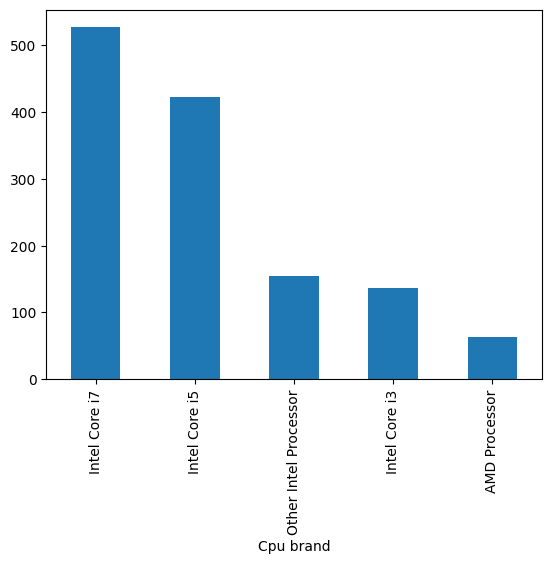

In [60]:
df['Cpu brand'].value_counts().plot(kind='bar')

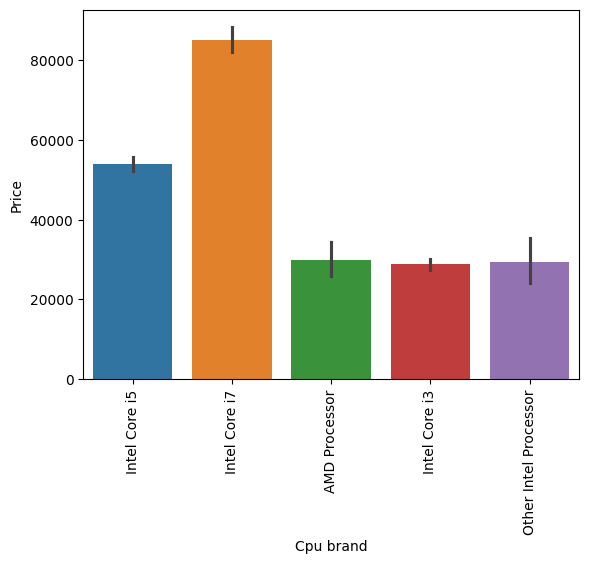

In [61]:
sns.barplot(x = df['Cpu brand'], y = df['Price'], hue = df['Cpu brand'])
plt.xticks(rotation='vertical')
plt.show()

In [62]:
df.drop(columns = ['Cpu', 'Cpu Name'], inplace=True)

In [63]:
df.sample(5)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi,Cpu brand
1234,Apple,Ultrabook,4,256GB Flash Storage,Intel HD Graphics 6000,Mac OS X,1.08,51095.5200,0,0,135.094211,Intel Core i5
1009,HP,Notebook,4,500GB HDD,Intel HD Graphics 620,Windows 10,1.64,36443.5200,0,0,111.935204,Intel Core i3
1092,Asus,Gaming,8,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,2.70,85194.7200,0,1,127.335675,Intel Core i7
1034,HP,Notebook,8,256GB SSD,Intel HD Graphics 520,Windows 10,1.84,65480.5872,0,0,141.211998,Intel Core i7
972,Dell,Gaming,32,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,4.42,149184.0000,0,0,127.335675,Intel Core i7


<Axes: xlabel='Ram'>

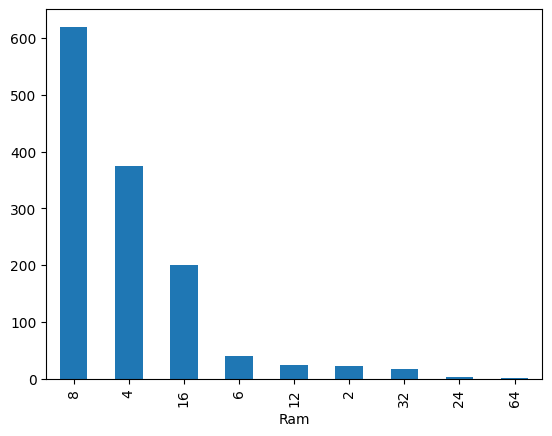

In [64]:
df['Ram'].value_counts().plot(kind='bar')

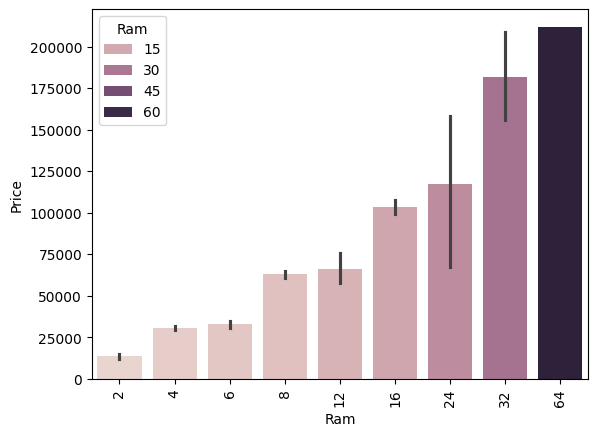

In [65]:
sns.barplot(x = df['Ram'], y = df['Price'], hue = df['Ram'])
plt.xticks(rotation='vertical')
plt.show()

In [66]:
df['Memory'].value_counts()

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
1TB SSD                           14
512GB SSD +  1TB HDD              14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
64GB SSD                       

In [67]:
df.sample(5)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi,Cpu brand
917,MSI,Gaming,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1050 Ti,Windows 10,2.70,85194.72,0,0,127.335675,Intel Core i7
697,Asus,2 in 1 Convertible,4,64GB Flash Storage,Intel HD Graphics 515,Chrome OS,1.20,35644.32,1,0,176.232574,Other Intel Processor
56,HP,Notebook,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.91,23389.92,0,0,141.211998,Intel Core i3
682,Dell,Gaming,16,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,3.21,109277.28,0,0,141.211998,Intel Core i5
164,Acer,Notebook,4,1TB HDD,Intel HD Graphics 500,Windows 10,2.10,18541.44,0,0,100.454670,Other Intel Processor


In [68]:
df['Memory'] = df['Memory'].astype(str)
df['Memory'] = df['Memory'].str.replace('.0', '', regex=False)
df['Memory'] = df['Memory'].str.replace('GB', '', regex=False)
df['Memory'] = df['Memory'].str.replace('TB', '000', regex=False)

new = df['Memory'].str.split('+', n=1, expand=True)

df['first'] = new[0].str.strip()

df['second'] = new[1].fillna('0')

# Layer 1
df['Layer1HDD'] = df['first'].str.contains('HDD', na=False).astype(int)
df['Layer1SSD'] = df['first'].str.contains('SSD', na=False).astype(int)
df['Layer1Hybrid'] = df['first'].str.contains('Hybrid', na=False).astype(int)
df['Layer1Flash_Storage'] = df['first'].str.contains('Flash Storage', na=False).astype(int)

# Layer 2
df['Layer2HDD'] = df['second'].str.contains('HDD', na=False).astype(int)
df['Layer2SSD'] = df['second'].str.contains('SSD', na=False).astype(int)
df['Layer2Hybrid'] = df['second'].str.contains('Hybrid', na=False).astype(int)
df['Layer2Flash_Storage'] = df['second'].str.contains('Flash Storage', na=False).astype(int)

# Extract numbers
df['first'] = df['first'].str.replace(r'\D', '', regex=True)
df['second'] = df['second'].str.replace(r'\D', '', regex=True)

df['first'] = df['first'].replace('', '0')
df['second'] = df['second'].replace('', '0')

df['first'] = df['first'].astype(int)
df['second'] = df['second'].astype(int)

# Final storage columns
df['HDD'] = df['first'] * df['Layer1HDD'] + df['second'] * df['Layer2HDD']
df['SSD'] = df['first'] * df['Layer1SSD'] + df['second'] * df['Layer2SSD']
df['Hybrid'] = df['first'] * df['Layer1Hybrid'] + df['second'] * df['Layer2Hybrid']
df['Flash_Storage'] = (
    df['first'] * df['Layer1Flash_Storage']
    + df['second'] * df['Layer2Flash_Storage']
)

# Drop temporary columns
df.drop(columns=[
    'first','second',
    'Layer1HDD','Layer1SSD','Layer1Hybrid','Layer1Flash_Storage',
    'Layer2HDD','Layer2SSD','Layer2Hybrid','Layer2Flash_Storage'
], inplace=True)

In [69]:
df.sample(5)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage
1183,Acer,Notebook,4,500 HDD,Intel HD Graphics 500,Windows 10,2.10,17742.24,0,0,100.454670,Other Intel Processor,500,0,0,0
918,Dell,Gaming,16,128 SSD + 1000 HDD,Nvidia GeForce GTX 1050 Ti,Windows 10,2.60,71874.72,0,0,141.211998,Intel Core i7,1000,128,0,0
871,Lenovo,Notebook,4,1000 HDD,AMD Radeon R5 M430,No OS,2.20,25521.12,0,0,141.211998,Intel Core i3,1000,0,0,0
1200,Dell,Notebook,4,128 SSD,AMD Radeon R7 M440,Windows 10,2.30,26586.72,0,0,100.454670,Intel Core i3,0,128,0,0
190,Lenovo,2 in 1 Convertible,16,1000 SSD,Intel HD Graphics 620,Windows 10,1.42,150462.72,1,0,209.800683,Intel Core i7,0,1000,0,0


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        1303 non-null   object 
 1   TypeName       1303 non-null   object 
 2   Ram            1303 non-null   int64  
 3   Memory         1303 non-null   object 
 4   Gpu            1303 non-null   object 
 5   OpSys          1303 non-null   object 
 6   Weight         1303 non-null   float64
 7   Price          1303 non-null   float64
 8   Touchscreen    1303 non-null   int64  
 9   IPS            1303 non-null   int64  
 10  ppi            1303 non-null   float64
 11  Cpu brand      1303 non-null   object 
 12  HDD            1303 non-null   int64  
 13  SSD            1303 non-null   int64  
 14  Hybrid         1303 non-null   int64  
 15  Flash_Storage  1303 non-null   int64  
dtypes: float64(3), int64(7), object(6)
memory usage: 163.0+ KB


In [71]:
df.drop(columns=['Memory'], inplace=True)

In [72]:
df.sample(5)

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,0,128
50,Lenovo,2 in 1 Convertible,4,Intel HD Graphics 400,Android,0.69,16996.3200,1,1,224.173809,Other Intel Processor,0,0,0,64
663,HP,Notebook,6,AMD Radeon R5 M430,Windows 10,2.04,28717.9200,0,0,141.211998,Intel Core i3,1000,0,0,0
221,Lenovo,2 in 1 Convertible,8,Intel UHD Graphics 620,Windows 10,1.74,47898.7200,0,1,157.350512,Intel Core i5,0,256,0,0
91,Acer,Notebook,8,Nvidia GeForce MX150,Windows 10,2.20,36709.9200,0,0,141.211998,Intel Core i7,1000,0,0,0


In [73]:
df.corr(numeric_only=True)['Price']

Ram              0.743007
Weight           0.210370
Price            1.000000
Touchscreen      0.191226
IPS              0.252208
ppi              0.473487
HDD             -0.096441
SSD              0.670799
Hybrid           0.007989
Flash_Storage   -0.040511
Name: Price, dtype: float64

In [74]:
df.drop(columns=['Hybrid','Flash_Storage'], inplace=True)

In [75]:
df.sample(5)

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi,Cpu brand,HDD,SSD
775,Asus,2 in 1 Convertible,12,Nvidia GeForce 940MX,Windows 10,2.30,44701.9200,1,0,141.211998,Intel Core i7,2000,0
862,Toshiba,Notebook,4,Intel HD Graphics 620,Windows 10,1.05,68464.8000,0,0,165.632118,Intel Core i5,0,128
907,Acer,Notebook,4,Intel HD Graphics,Chrome OS,2.20,19127.5200,0,1,141.211998,Other Intel Processor,0,0
984,Toshiba,Notebook,4,Intel HD Graphics 520,Windows 10,1.75,48751.2000,0,0,111.935204,Intel Core i5,500,0
392,Acer,Notebook,12,Nvidia GeForce MX130,Windows 10,2.20,36975.7872,0,1,100.454670,Intel Core i5,1000,0


In [76]:
df['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      281
Intel HD Graphics 520      185
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
Nvidia Quadro M500M          1
AMD Radeon R7 M360           1
Nvidia Quadro M3000M         1
Nvidia GeForce 960M          1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64

In [77]:
df['Gpu brand'] =df['Gpu'].apply(lambda x:x.split()[0])
df['Gpu brand']

0       Intel
1       Intel
2       Intel
3         AMD
4       Intel
        ...  
1298    Intel
1299    Intel
1300    Intel
1301      AMD
1302    Intel
Name: Gpu brand, Length: 1303, dtype: object

In [78]:
df.head()

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi,Cpu brand,HDD,SSD,Gpu brand
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel


In [79]:
df['Gpu brand'].value_counts()

Gpu brand
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

In [80]:
df.shape

(1303, 14)

In [81]:
df = df[df['Gpu brand'] != 'ARM']

In [82]:
df.shape

(1302, 14)

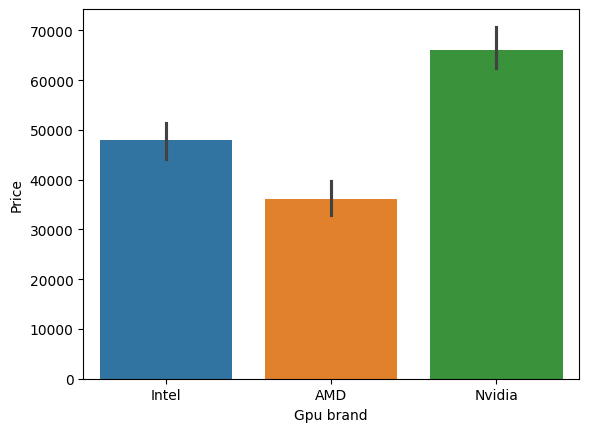

In [83]:
sns.barplot(x=df['Gpu brand'], y=df['Price'], hue=df['Gpu brand'],estimator=np.median)
plt.show()

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1302 entries, 0 to 1302
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1302 non-null   object 
 1   TypeName     1302 non-null   object 
 2   Ram          1302 non-null   int64  
 3   Gpu          1302 non-null   object 
 4   OpSys        1302 non-null   object 
 5   Weight       1302 non-null   float64
 6   Price        1302 non-null   float64
 7   Touchscreen  1302 non-null   int64  
 8   IPS          1302 non-null   int64  
 9   ppi          1302 non-null   float64
 10  Cpu brand    1302 non-null   object 
 11  HDD          1302 non-null   int64  
 12  SSD          1302 non-null   int64  
 13  Gpu brand    1302 non-null   object 
dtypes: float64(3), int64(5), object(6)
memory usage: 152.6+ KB


In [85]:
df.drop(columns=['Gpu'], inplace=True)

In [86]:
df['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

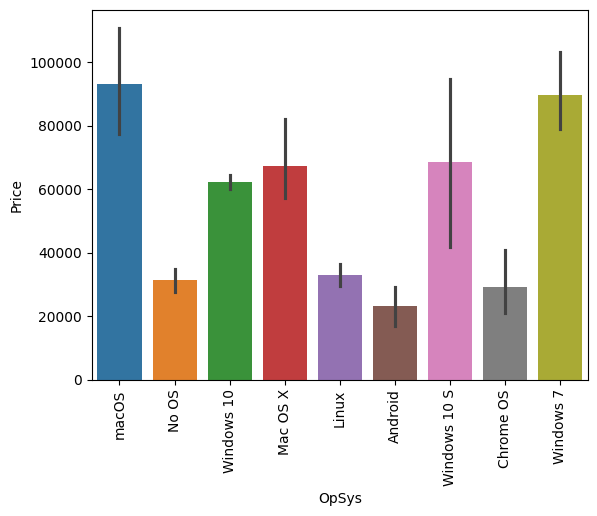

In [87]:
sns.barplot(x=df['OpSys'],y=df['Price'],hue=df['OpSys'])
plt.xticks(rotation='vertical')
plt.show()

In [88]:
def cat_os(inp):
    if inp == 'Windows 10' or inp == 'Windows 7' or inp == 'Windows 10 S':
        return 'Windows'
    elif inp == 'macOS' or inp == 'Mac OS X':
        return 'Mac'
    else:
        return 'Other/No OS/Linux'

In [89]:
df['os'] = df['OpSys'].apply(cat_os) 

In [90]:
df.sample(5)

,Company,TypeName,Ram,OpSys,Weight,Price,Touchscreen,IPS,ppi,Cpu brand,HDD,SSD,Gpu brand,os
173,Toshiba,Notebook,4,Windows 10,2.00,26053.92,0,0,100.454670,Intel Core i3,500,0,Intel,Windows
236,Acer,Notebook,4,Linux,2.10,20779.20,0,0,100.454670,Intel Core i3,1000,0,Intel,Other/No OS/Linux
492,Asus,Gaming,8,Windows 10,1.99,71928.00,0,0,141.211998,Intel Core i7,1000,128,Nvidia,Windows
346,HP,Notebook,2,Windows 10,1.44,14865.12,0,0,111.935204,Other Intel Processor,0,0,Intel,Windows
1044,HP,Notebook,4,Windows 10,1.54,53280.00,0,0,157.350512,Intel Core i5,500,0,Intel,Windows


In [91]:
df.drop(columns=['OpSys'], inplace=True)

In [92]:
df.sample(5)

,Company,TypeName,Ram,Weight,Price,Touchscreen,IPS,ppi,Cpu brand,HDD,SSD,Gpu brand,os
459,HP,Notebook,8,2.50,34093.872,0,0,106.113062,Intel Core i3,0,256,Intel,Windows
107,Asus,Ultrabook,8,1.30,63563.040,0,1,157.350512,Intel Core i7,0,256,Nvidia,Windows
1177,Lenovo,Gaming,16,3.31,69530.400,0,1,141.211998,Intel Core i7,0,512,Nvidia,Windows
1097,MSI,Gaming,8,2.60,85194.720,0,0,127.335675,Intel Core i7,0,256,Nvidia,Windows
609,Acer,Notebook,4,1.60,18594.720,0,0,111.935204,Other Intel Processor,0,0,Intel,Windows


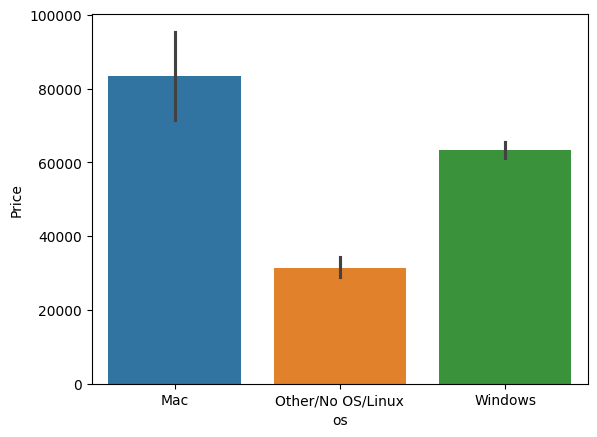

In [93]:
sns.barplot(x=df['os'],y=df['Price'],hue=df['os'])
#plt.xticks(rotation='vertical')
plt.show()

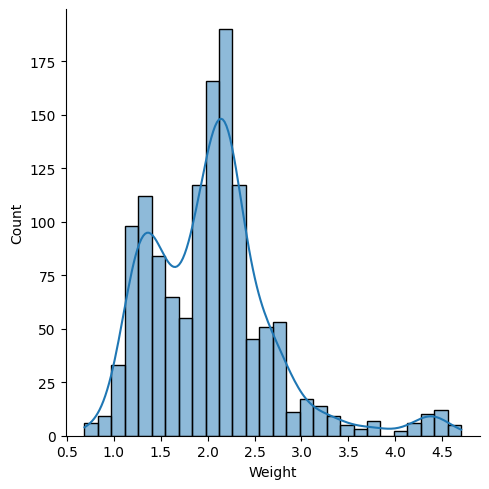

In [94]:
sns.displot(df['Weight'], kde=True)

<Axes: xlabel='Weight', ylabel='Price'>

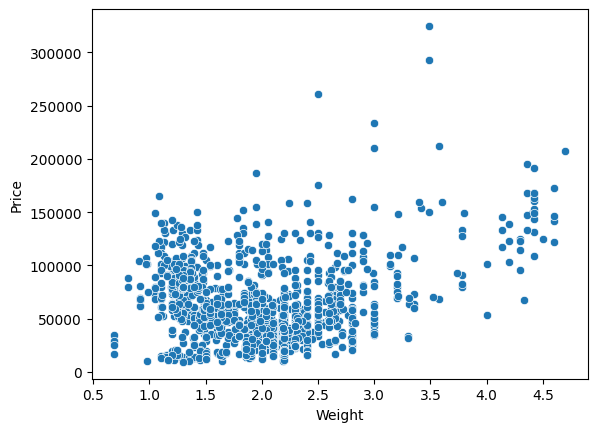

In [95]:
sns.scatterplot(x=df['Weight'],y=df['Price'])

In [96]:
df.corr(numeric_only=True)['Price']

Ram            0.742905
Weight         0.209867
Price          1.000000
Touchscreen    0.192917
IPS            0.253320
ppi            0.475368
HDD           -0.096891
SSD            0.670660
Name: Price, dtype: float64

In [97]:
df.corr(numeric_only=True)

,Ram,Weight,Price,Touchscreen,IPS,ppi,HDD,SSD
Ram,1.000000,0.383362,0.742905,0.118875,0.207949,0.305688,0.095808,0.603379
Weight,0.383362,1.000000,0.209867,-0.293004,0.018643,-0.321883,0.514147,-0.063818
Price,0.742905,0.209867,1.000000,0.192917,0.253320,0.475368,-0.096891,0.670660
Touchscreen,0.118875,-0.293004,0.192917,1.000000,0.148026,0.458571,-0.208766,0.257577
IPS,0.207949,0.018643,0.253320,0.148026,1.000000,0.299142,-0.093588,0.225311
ppi,0.305688,-0.321883,0.475368,0.458571,0.299142,1.000000,-0.294698,0.509437
HDD,0.095808,0.514147,-0.096891,-0.208766,-0.093588,-0.294698,1.000000,-0.400750
SSD,0.603379,-0.063818,0.670660,0.257577,0.225311,0.509437,-0.400750,1.000000


<Axes: >

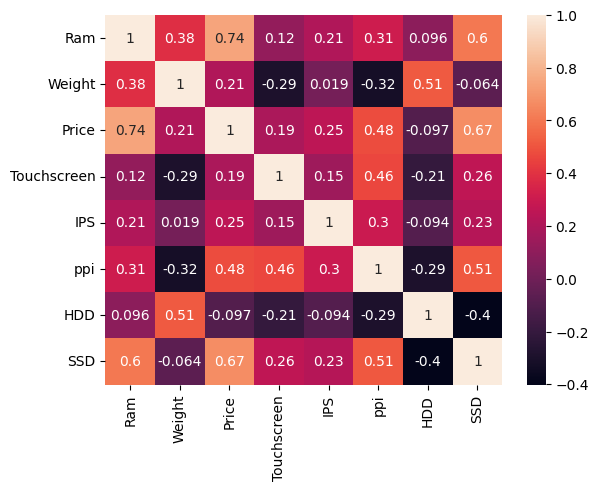

In [98]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

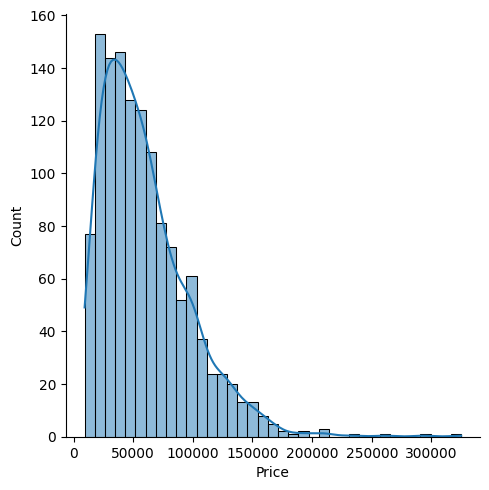

In [99]:
sns.displot(df['Price'], kde=True)

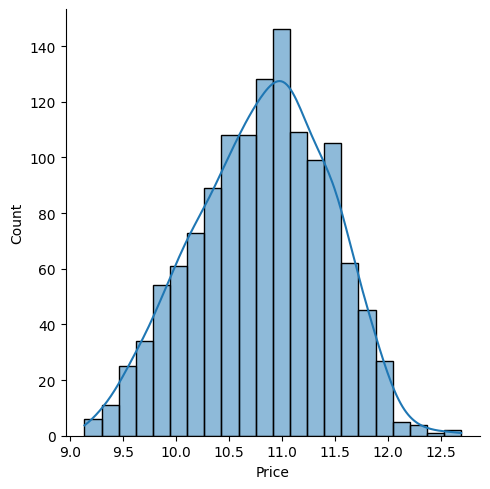

In [100]:
sns.displot(np.log(df['Price']), kde=True)

### Separate the target column (`Price`) from the feature set, and apply a log transformation to the target variable.

In [101]:
X = df.drop(columns=['Price'])
y = np.log(df['Price'])

In [102]:
X

,Company,TypeName,Ram,Weight,Touchscreen,IPS,ppi,Cpu brand,HDD,SSD,Gpu brand,os
0,Apple,Ultrabook,8,1.37,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,0,0,141.211998,Intel Core i5,0,256,Intel,Other/No OS/Linux
3,Apple,Ultrabook,16,1.83,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,0,1,226.983005,Intel Core i5,0,256,Intel,Mac
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,4,1.80,1,1,157.350512,Intel Core i7,0,128,Intel,Windows
1299,Lenovo,2 in 1 Convertible,16,1.30,1,1,276.053530,Intel Core i7,0,512,Intel,Windows
1300,Lenovo,Notebook,2,1.50,0,0,111.935204,Other Intel Processor,0,0,Intel,Windows
1301,HP,Notebook,6,2.19,0,0,100.454670,Intel Core i7,1000,0,AMD,Windows


In [103]:
y

0       11.175755
1       10.776777
2       10.329931
3       11.814476
4       11.473101
          ...    
1298    10.433899
1299    11.288115
1300     9.409283
1301    10.614129
1302     9.886358
Name: Price, Length: 1302, dtype: float64

### Split the data into Train and Test sets

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.15,random_state=2)

In [105]:
X_train

,Company,TypeName,Ram,Weight,Touchscreen,IPS,ppi,Cpu brand,HDD,SSD,Gpu brand,os
183,Toshiba,Notebook,8,2.00,0,0,100.454670,Intel Core i5,0,128,Intel,Windows
1141,MSI,Gaming,8,2.40,0,0,141.211998,Intel Core i7,1000,128,Nvidia,Windows
1049,Asus,Netbook,4,1.20,0,0,135.094211,Other Intel Processor,0,0,Intel,Other/No OS/Linux
1020,Dell,2 in 1 Convertible,4,2.08,1,1,141.211998,Intel Core i3,1000,0,Intel,Windows
878,Dell,Notebook,4,2.18,0,0,141.211998,Intel Core i5,1000,128,Nvidia,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...
466,Acer,Notebook,4,2.20,0,0,100.454670,Intel Core i3,500,0,Nvidia,Windows
299,Asus,Ultrabook,16,1.63,0,0,141.211998,Intel Core i7,0,512,Nvidia,Windows
493,Acer,Notebook,8,2.20,0,0,100.454670,AMD Processor,1000,0,AMD,Windows
527,Lenovo,Notebook,8,2.20,0,0,100.454670,Intel Core i3,2000,0,Nvidia,Other/No OS/Linux


# Now we try different ML Algorithms

## 1. Linear Regression

In [106]:
step1 = ColumnTransformer(transformers=[
    ('col_trf', OneHotEncoder(sparse_output=False, drop='first'), [0,1,7,10,11])
],remainder = 'passthrough')


step2 = LinearRegression()

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print('R2 Score:',r2_score(y_test, y_pred))
print('MAE :',mean_absolute_error(y_test, y_pred))

R2 Score: 0.8073277450155159
MAE : 0.21017827953018972


## 2. Ridge Regression

In [107]:
step1 = ColumnTransformer(transformers=[
    ('col_trf', OneHotEncoder(sparse_output=False, drop='first'), [0,1,7,10,11])
],remainder = 'passthrough')


step2 = Ridge(alpha=10)

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print('R2 Score:',r2_score(y_test, y_pred))
print('MAE :',mean_absolute_error(y_test, y_pred))

R2 Score: 0.812733103373946
MAE : 0.20926802210371445


## 3. Lasso Regression

In [108]:
step1 = ColumnTransformer(transformers=[
    ('col_trf', OneHotEncoder(sparse_output=False, drop='first'), [0,1,7,10,11])
],remainder = 'passthrough')


step2 = Lasso(alpha=0.001)

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print('R2 Score:',r2_score(y_test, y_pred))
print('MAE :',mean_absolute_error(y_test, y_pred))

R2 Score: 0.8071853947620582
MAE : 0.21114361575113452


## 4. KNN

In [109]:
step1 = ColumnTransformer(transformers=[
    ('col_trf', OneHotEncoder(sparse_output=False, drop='first'), [0,1,7,10,11])
],remainder = 'passthrough')


step2 = KNeighborsRegressor(n_neighbors=3)

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print('R2 Score:',r2_score(y_test, y_pred))
print('MAE :',mean_absolute_error(y_test, y_pred))

R2 Score: 0.802621370279362
MAE : 0.19362782156545677


## 5. Decision Tree

In [110]:
step1 = ColumnTransformer(transformers=[
    ('col_trf', OneHotEncoder(sparse_output=False, drop='first'), [0,1,7,10,11])
],remainder = 'passthrough')


step2 = DecisionTreeRegressor(max_depth=8)

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print('R2 Score:',r2_score(y_test, y_pred))
print('MAE :',mean_absolute_error(y_test, y_pred))

R2 Score: 0.8405270612856596
MAE : 0.18109777244865177


In [112]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

# Preprocessing
step1 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False),
         [0, 1, 7, 10, 11])
    ],
    remainder='passthrough'
)

# Pipeline
pipe = Pipeline([
    ('preprocessor', step1),
    ('model', DecisionTreeRegressor(random_state=42))
])

# Hyperparameter grid
params = {
    'model__max_depth': [5, 8, 10, 15, 20, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 4, 8]
}

# Grid Search
grid = GridSearchCV(
    pipe,
    param_grid=params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

# Prediction
y_pred = best_model.predict(X_test)

# Results
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
print("Test R2 Score:", r2_score(y_test, y_pred))
print("Test MAE:", mean_absolute_error(y_test, y_pred))

Best Parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10}
Best CV Score: 0.8144190679370655
Test R2 Score: 0.8538914886530764
Test MAE: 0.18108956042480895


## 6. SVM

In [114]:
step1 = ColumnTransformer(transformers=[
    ('col_trf', OneHotEncoder(sparse_output=False, drop='first'), [0,1,7,10,11])
],remainder = 'passthrough')


step2 = SVR(kernel='rbf', C=10000, epsilon=0.1,gamma='scale')

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print('R2 Score:',r2_score(y_test, y_pred))
print('MAE :',mean_absolute_error(y_test, y_pred))

R2 Score: 0.8083168388455474
MAE : 0.20239400567647914


## 7. Random Forest

In [115]:
step1 = ColumnTransformer(transformers=[
    ('col_trf', OneHotEncoder(sparse_output=False, drop='first'), [0,1,7,10,11])
],remainder = 'passthrough')


step2 = RandomForestRegressor(
    n_estimators=100,
    random_state=3,
    max_samples=0.5,
    max_features=0.75,
    max_depth=15
)

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print('R2 Score:',r2_score(y_test, y_pred))
print('MAE :',mean_absolute_error(y_test, y_pred))

R2 Score: 0.8873402378382488
MAE : 0.15860130110457718


In [116]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

# Preprocessing
step1 = ColumnTransformer(
    transformers=[
        ('col_trf',
         OneHotEncoder(sparse_output=False, drop='first'),
         [0,1,7,10,11])
    ],
    remainder='passthrough'
)

# Model
step2 = RandomForestRegressor(random_state=42)

# Pipeline
pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

# Hyperparameter space
params = {
    'step2__n_estimators': [100, 200, 300, 500],
    'step2__max_depth': [10, 15, 20, 30, None],
    'step2__max_features': ['sqrt', 'log2', 0.5, 0.75, 1.0],
    'step2__min_samples_split': [2, 5, 10],
    'step2__min_samples_leaf': [1, 2, 4],
    'step2__max_samples': [0.5, 0.75, None]
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=params,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("Best Parameters:")
print(search.best_params_)

best_model = search.best_estimator_

y_pred = best_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

Best Parameters:
{'step2__n_estimators': 300, 'step2__min_samples_split': 5, 'step2__min_samples_leaf': 1, 'step2__max_samples': None, 'step2__max_features': 0.75, 'step2__max_depth': 15}
R2 Score: 0.8879175366201263
MAE: 0.15760541163482425


## 8. Extra Tress

In [118]:
step1 = ColumnTransformer(transformers=[
    ('col_trf', OneHotEncoder(sparse_output=False, drop='first'), [0,1,7,10,11])
],remainder = 'passthrough')


step2 = ExtraTreesRegressor(
    n_estimators=100,
    random_state=3,
    # max_samples=0.5,
    max_features=0.75,
    max_depth=15
)

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print('R2 Score:',r2_score(y_test, y_pred))
print('MAE :',mean_absolute_error(y_test, y_pred))

R2 Score: 0.8753793123440623
MAE : 0.15979519126758127


## 9. AdaBoost

In [131]:
step1 = ColumnTransformer(transformers=[
    ('col_trf', OneHotEncoder(sparse_output=False, drop='first'), [0,1,7,10,11])
],remainder = 'passthrough')


step2 = AdaBoostRegressor(n_estimators=150,learning_rate=1.0)

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print('R2 Score:',r2_score(y_test, y_pred))
print('MAE :',mean_absolute_error(y_test, y_pred))

R2 Score: 0.8010910594242322
MAE : 0.2243695600082445


## 10. GradientBoost

In [127]:
step1 = ColumnTransformer(transformers=[
    ('col_trf', OneHotEncoder(sparse_output=False, drop='first'), [0,1,7,10,11])
],remainder = 'passthrough')


step2 = GradientBoostingRegressor(n_estimators = 500)

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print('R2 Score:',r2_score(y_test, y_pred))
print('MAE :',mean_absolute_error(y_test, y_pred))

R2 Score: 0.8841257448007487
MAE : 0.15877476188445963


## 11. XGBoost

In [132]:
step1 = ColumnTransformer(transformers=[
    ('col_trf', OneHotEncoder(sparse_output=False, drop='first'), [0,1,7,10,11])
],remainder = 'passthrough')


step2 = XGBRegressor(n_estimators = 45 , max_depth=5,learning_rate=0.5)

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print('R2 Score:',r2_score(y_test, y_pred))
print('MAE :',mean_absolute_error(y_test, y_pred))

R2 Score: 0.8771404806375557
MAE : 0.16262936288951352


## 12. Voting Regressor

In [134]:
step1 = ColumnTransformer(transformers=[
    ('col_trf', OneHotEncoder(sparse_output=False, drop='first'), [0,1,7,10,11])
],remainder = 'passthrough')

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=3,
    max_samples=0.5,
    max_features=0.75,
    max_depth=15
)
gbdt = GradientBoostingRegressor(n_estimators = 100, max_features=0.5)
xgb = XGBRegressor(n_estimators = 25 , max_depth=5,learning_rate=0.3)
et = ExtraTreesRegressor(
    n_estimators=100,
    random_state=3,
    # max_samples=0.5,
    max_features=0.75,
    max_depth=15
)


step2 = VotingRegressor([('rf', rf), ('gbdt', gbdt), ('xgb', xgb), ('et', et)])


pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print('R2 Score:',r2_score(y_test, y_pred))
print('MAE :',mean_absolute_error(y_test, y_pred))

R2 Score: 0.8884263930675205
MAE : 0.1589196344367783


## Final model(Random Forest)

In [136]:
step1 = ColumnTransformer(transformers=[
    ('col_trf', OneHotEncoder(sparse_output=False, drop='first'), [0,1,7,10,11])
],remainder = 'passthrough')


step2 = RandomForestRegressor(
    n_estimators=100,
    random_state=3,
    max_samples=0.5,
    max_features=0.75,
    max_depth=15
)

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print('R2 Score:',r2_score(y_test, y_pred))
print('MAE :',mean_absolute_error(y_test, y_pred))

R2 Score: 0.8873402378382488
MAE : 0.15860130110457718


## Exporting the model

In [137]:
import pickle

pickle.dump(df, open('df.pkl', 'wb'))
pickle.dump(pipe, open('pipe.pkl', 'wb'))